In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.base import BaseEstimator, TransformerMixin

import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.optim as optim
from torchtext.data import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
import nltk
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import re
import string




In [4]:
# nltk.download(['punkt', 'stopwords', 'wordnet'])

In [5]:
class TweetCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, filepath, encoding='latin1'):
        self.df = pd.read_csv(filepath, encoding=encoding)
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

    def preprocess_text(self, text):
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#\w+', '', text)
        text = re.sub(r'http\S+', '', text)
        text = re.sub(r'\d+', '', text)
        text = text.translate(str.maketrans('', '', string.punctuation))

        emoji_pattern = re.compile(
            "["                  
            u"\U0001F600-\U0001F64F"  
            u"\U0001F300-\U0001F5FF"  
            u"\U0001F680-\U0001F6FF"  
            u"\U0001F1E0-\U0001F1FF"  
            u"\U00002700-\U000027BF"
            u"\U000024C2-\U0001F251"
            "]+", flags=re.UNICODE)

        text = emoji_pattern.sub(r'', text)
        text = text.lower()
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def remove_stopwords(self, text):
        return ' '.join([word for word in text.split() if word not in self.stop_words])

    def lemmatize_text(self, text):
        return ' '.join([self.lemmatizer.lemmatize(word) for word in text.split()])

    def _is_english(self, text):
        try:
            return len(text.strip()) > 5 and detect(text) == 'en'
        except:
            return False

    def handle_missing_values(self):
        self.df.dropna(subset=['tweet_text'], inplace=True)
        self.df['emotion_in_tweet_is_directed_at'] = self.df['emotion_in_tweet_is_directed_at'].fillna('Unknown')
        return self.df

    def full_text_processing(self):
        self.df.dropna(subset=['tweet_text'], inplace=True)
        self.df.drop_duplicates(subset=['tweet_text'], inplace=True)
        self.df = self.df[self.df['tweet_text'].apply(self._is_english)]
        self.df = self.df[~self.df['tweet_text'].str.contains('�')]

        self.df['cleaned_text'] = self.df['tweet_text'].astype(str).apply(self.preprocess_text)
        self.df['cleaned_text'] = self.df['cleaned_text'].apply(self.remove_stopwords)
        self.df['cleaned_text'] = self.df['cleaned_text'].apply(self.lemmatize_text)

        return self.df


In [6]:
cleaner = TweetCleaner('judge-1377884607_tweet_product_company.csv', encoding='latin1')
cleaner.full_text_processing()
cleaner.handle_missing_values()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product,cleaned_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,g iphone hr tweeting dead need upgrade plugin ...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion,know awesome ipadiphone app youll likely appre...
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,wait also sale
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion,hope year festival isnt crashy year iphone app
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,great stuff fri marissa mayer google tim oreil...
...,...,...,...,...
9088,Ipad everywhere. #SXSW {link},iPad,Positive emotion,ipad everywhere link
9089,"Wave, buzz... RT @mention We interrupt your re...",Unknown,No emotion toward brand or product,wave buzz rt interrupt regularly scheduled gee...
9090,"Google's Zeiger, a physician never reported po...",Unknown,No emotion toward brand or product,google zeiger physician never reported potenti...
9091,Some Verizon iPhone customers complained their...,Unknown,No emotion toward brand or product,verizon iphone customer complained time fell b...


In [7]:
cleaner.df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9001 entries, 0 to 9092
Data columns (total 4 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9001 non-null   object
 1   emotion_in_tweet_is_directed_at                     9001 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9001 non-null   object
 3   cleaned_text                                        9001 non-null   object
dtypes: object(4)
memory usage: 351.6+ KB


In [8]:
cleaner.df.describe()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product,cleaned_text
count,9001,9001,9001,9001
unique,9001,10,4,8563
top,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,Unknown,No emotion toward brand or product,rt google launch major new social network call...
freq,1,5738,5326,21


In [9]:
cleaner.df.shape

(9001, 4)

In [10]:
# Remove duplicates
cleaner.df = cleaner.df.drop_duplicates(subset=['tweet_text'])
cleaner.df = cleaner.df[~cleaner.df['tweet_text'].str.contains('�')]

In [11]:
cleaner.df.isnull().sum()

tweet_text                                            0
emotion_in_tweet_is_directed_at                       0
is_there_an_emotion_directed_at_a_brand_or_product    0
cleaned_text                                          0
dtype: int64

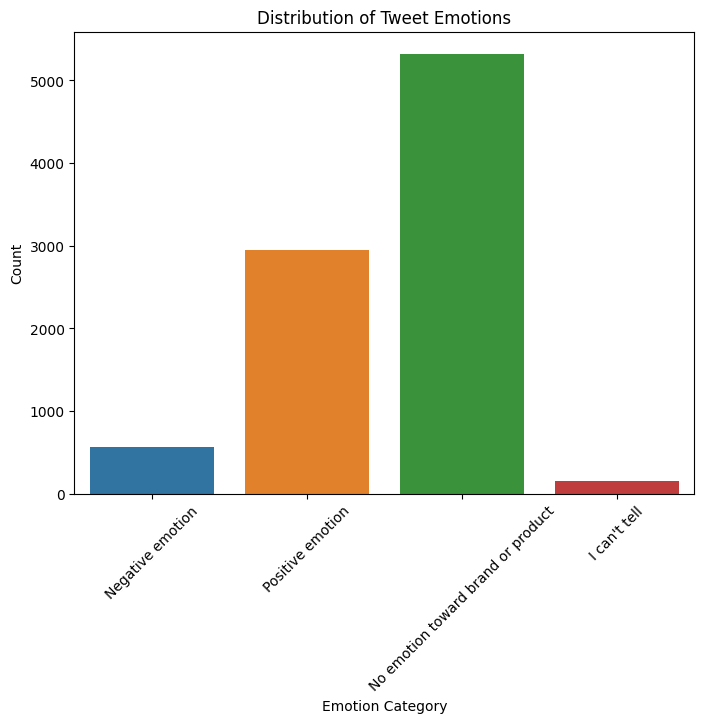

In [12]:
# Class Distribution Plot
plt.figure(figsize=(8, 6))
sns.countplot(data=cleaner.df, x='is_there_an_emotion_directed_at_a_brand_or_product')
plt.title('Distribution of Tweet Emotions')
plt.xlabel('Emotion Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


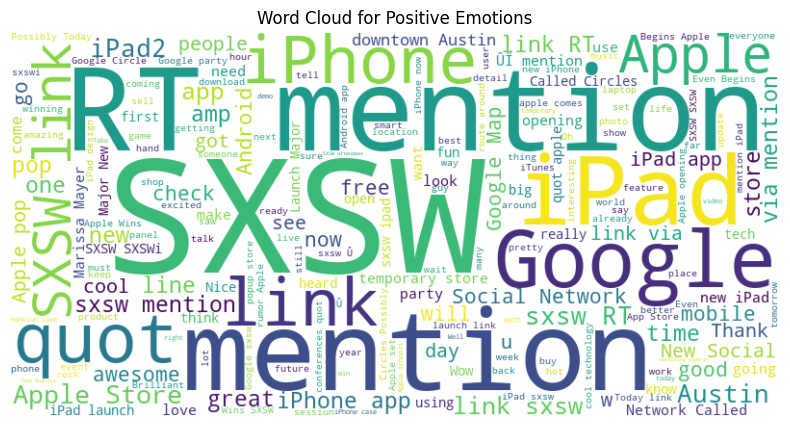

In [13]:
# Word Cloud for Positive Emotions
from wordcloud import WordCloud

positive_tweets = cleaner.df[cleaner.df['is_there_an_emotion_directed_at_a_brand_or_product'] == 'Positive emotion']['tweet_text']
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(positive_tweets))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Emotions')
plt.show()

In [14]:
cleaner.df.rename(columns={'emotion_in_tweet_is_directed_at':'emotion_towards','is_there_an_emotion_directed_at_a_brand_or_product':'emotion_reaction'},inplace=True)

In [15]:
neutral_labels = ["I can't tell", "No emotion toward brand or product"]

cleaner.df["emotion_reaction_updated"] = cleaner.df["emotion_reaction"].replace({
    label: "Neutral" for label in neutral_labels
})


In [31]:
cleaner = TweetCleaner(cleaner.df)


In [16]:
# Encode target variable
le = LabelEncoder()
cleaner.df['emotion_encoded'] = le.fit_transform(cleaner.df['emotion_reaction'])
cleaner.df.head()

,tweet_text,emotion_towards,emotion_reaction,cleaned_text,emotion_reaction_updated,emotion_encoded
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,g iphone hr tweeting dead need upgrade plugin ...,Negative emotion,1
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion,know awesome ipadiphone app youll likely appre...,Positive emotion,3
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,wait also sale,Positive emotion,3
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion,hope year festival isnt crashy year iphone app,Negative emotion,1
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,great stuff fri marissa mayer google tim oreil...,Positive emotion,3


In [17]:
# Prepare features and target
text_column = 'cleaned_text'
target_column = 'emotion_encoded'


In [18]:
class TweetCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, output_format='string'):
        self.output_format = output_format
        

    def fit(self, X, y=None):
    
        return self

    def transform(self, X):
        
        cleaned_texts = []
        for text in X:
        
            cleaned = self.clean_text(text)  
            cleaned_texts.append(cleaned)

        if self.output_format == 'string':
            return pd.Series(cleaned_texts)
        elif self.output_format == 'list':
            return cleaned_texts
        else:
            return cleaned_texts

    
    def clean_text(self, text):
        
        return text.lower()  


In [19]:
from sklearn.ensemble import StackingClassifier

text_pipeline = Pipeline([
    ('preprocess', TweetCleaner(output_format='string')),
    ('vectorizer', TfidfVectorizer())
])

# Base models
estimators = [
    ('lr', LogisticRegression(solver='liblinear')),
    ('svc', SVC(probability=True)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0))
]

# Stacking classifier
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=1
)

# Full pipeline: text preprocessing + stacking model
pipeline = Pipeline([
    ('text', text_pipeline),
    ('model', stack_model)
])

In [20]:
print(cleaner.df.columns.tolist())


['tweet_text', 'emotion_towards', 'emotion_reaction', 'cleaned_text', 'emotion_reaction_updated', 'emotion_encoded']


In [21]:
columns_to_keep = ['cleaned_text', 'emotion_reaction_updated']
cleaner.df = cleaner.df[columns_to_keep]


In [23]:
cleaner.df = cleaner.df.dropna(subset=['cleaned_text'])

X = cleaner.df['cleaned_text']
y = cleaner.df['emotion_reaction_updated']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('text',
                 Pipeline(steps=[('preprocess', TweetCleaner()),
                                 ('vectorizer', TfidfVectorizer())])),
                ('model',
                 StackingClassifier(cv=5,
                                    estimators=[('lr',
                                                 LogisticRegression(solver='liblinear')),
                                                ('svc', SVC(probability=True)),
                                                ('rf',
                                                 RandomForestClassifier(random_state=42)),
                                                ('xgb',
                                                 XGBClassifier(base_score=None,
                                                               booster=None,
                                                               callbacks=None,
                                                               colsample_b...
                                                               importance_type=None,
                                                               interaction_constraints=None,
                                                               learning_rate=None,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=None,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=None,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...))],
                                    final_estimator=LogisticRegression(),
                                    n_jobs=1))])

In [24]:
from sklearn.metrics import classification_report

y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

                  precision    recall  f1-score   support

Negative emotion       0.71      0.19      0.30       161
         Neutral       0.72      0.87      0.79      1354
Positive emotion       0.66      0.51      0.57       736

        accuracy                           0.70      2251
       macro avg       0.70      0.52      0.55      2251
    weighted avg       0.70      0.70      0.68      2251



In [25]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

class TextClassifier:
    def __init__(self, model, use_smote=False, max_features=5000):
        self.model = model
        self.use_smote = use_smote
        self.max_features = max_features
        self.pipeline = self._build_pipeline()

    def _build_pipeline(self):
        steps = [('vectorizer', TfidfVectorizer(max_features=self.max_features))]
        if self.use_smote:
            steps.append(('smote', SMOTE(random_state=42)))
            pipeline = ImbPipeline(steps + [('clf', self.model)])
        else:
            pipeline = Pipeline(steps + [('clf', self.model)])
        return pipeline

    def train(self, X_train, y_train):
        self.pipeline.fit(X_train, y_train)

    def predict(self, X_test):
        return self.pipeline.predict(X_test)

    def evaluate(self, X_test, y_test):
        y_pred = self.predict(X_test)
        print(classification_report(y_test, y_pred))


In [27]:
class ModelComparer:
    def __init__(self, models_dict, use_smote=False):
        self.models_dict = models_dict
        self.use_smote = use_smote
        self.results = {}

    def compare(self, X_train, X_test, y_train, y_test):
        for name, model in self.models_dict.items():
            print(f"\nTraining & Evaluating: {name}")
            classifier = TextClassifier(model=model, use_smote=self.use_smote)
            classifier.train(X_train, y_train)
            print(f"--- {name} Classification Report ---")
            classifier.evaluate(X_test, y_test)


In [33]:
cleaner.df['emotion_encoded'] = cleaner.df['emotion_reaction_updated'].astype('category').cat.codes

X_train, X_test, y_train, y_test = cleaner.split_data()

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

class TweetCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, df):
        self.df = df

    def split_data(self, text_column='cleaned_text', target_column='emotion_encoded', test_size=0.2, random_state=42):
        X = self.df[text_column]
        y = self.df[target_column]
        return train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)

# 1. Define your models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'SVC': SVC(probability=True)
}

# 2. Split your data
X_train, X_test, y_train, y_test = cleaner.split_data()

# 3. Compare models (set use_smote=True to handle imbalance)
comparer = ModelComparer(models_dict=models, use_smote=True)
comparer.compare(X_train, X_test, y_train, y_test)



Training & Evaluating: Logistic Regression
--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.32      0.48      0.38       114
           1       0.75      0.68      0.71      1097
           2       0.54      0.57      0.56       590

    accuracy                           0.63      1801
   macro avg       0.54      0.58      0.55      1801
weighted avg       0.65      0.63      0.64      1801


Training & Evaluating: Random Forest
--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.63      0.27      0.38       114
           1       0.71      0.84      0.77      1097
           2       0.62      0.47      0.54       590

    accuracy                           0.68      1801
   macro avg       0.65      0.53      0.56      1801
weighted avg       0.68      0.68      0.67      1801


Training & Evaluating: XGBoost
--- XGBoost Classification Rep

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

param_grid = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l2'],
    'clf__solver': ['liblinear']
}

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000))
])

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))


Best params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.55      0.26      0.36       114
           1       0.73      0.82      0.77      1097
           2       0.61      0.54      0.57       590

    accuracy                           0.69      1801
   macro avg       0.63      0.54      0.57      1801
weighted avg       0.68      0.69      0.68      1801



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Choose vectorizer
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=10000)  

# Build pipeline
pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('clf', LogisticRegression(C=10, penalty='l2', solver='liblinear', max_iter=1000))
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.54      0.23      0.32       114
           1       0.72      0.81      0.76      1097
           2       0.60      0.54      0.56       590

    accuracy                           0.68      1801
   macro avg       0.62      0.52      0.55      1801
weighted avg       0.67      0.68      0.67      1801



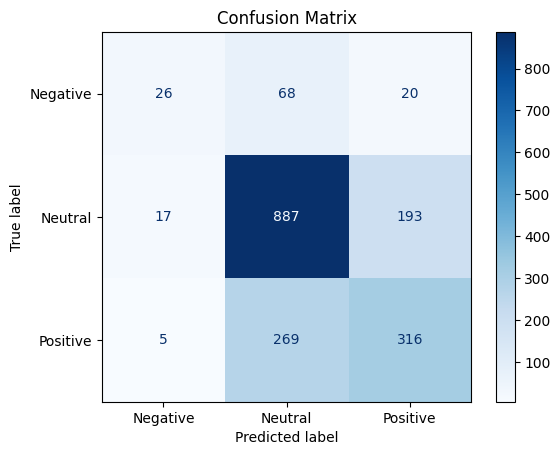

In [40]:

cm = confusion_matrix(y_test, y_pred)

# Visualize
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Neutral', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


              precision    recall  f1-score   support

    Negative       0.51      0.32      0.39       114
     Neutral       0.73      0.79      0.76      1097
    Positive       0.59      0.56      0.57       590

    accuracy                           0.68      1801
   macro avg       0.61      0.55      0.57      1801
weighted avg       0.67      0.68      0.68      1801



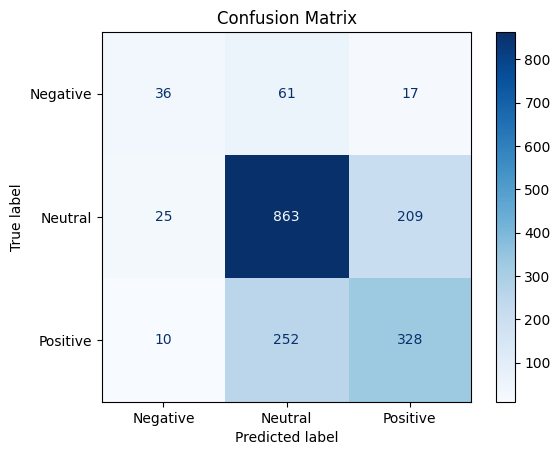

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=10000)  

pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('clf', LogisticRegression(C=10, penalty='l2', solver='liblinear', max_iter=1000))
])

#  Train the model
pipeline.fit(X_train, y_train)

# Predict on test data
y_pred = pipeline.predict(X_test)

# Print classification report
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Neutral', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


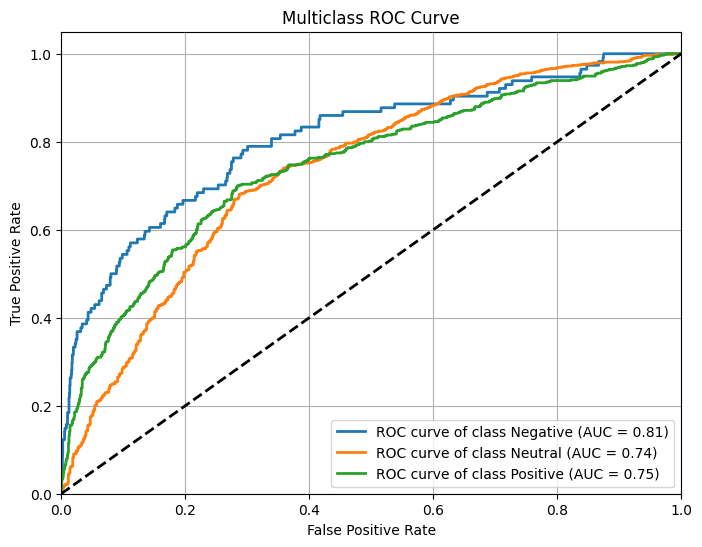

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
classes = ['Negative', 'Neutral', 'Positive']
y_test_binarized = label_binarize(y_test, classes=[0,1,2])  
n_classes = y_test_binarized.shape[1]

y_score = pipeline.predict_proba(X_test)

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve of class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
